In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
X_train = pd.read_csv(r"../data/X_train.csv")
X_test = pd.read_csv(r"../data/X_test.csv")
y_train = pd.read_csv(r"../data/y_train.csv")
y_test = pd.read_csv(r"../data/y_test.csv")

In [3]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((59954, 92), (59954, 1), (14989, 92), (14989, 1))

In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.linear_model import LinearRegression, Ridge,Lasso,ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [5]:
from sklearn.linear_model import LinearRegression

In [6]:
regression=LinearRegression()

In [7]:
regression.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
## print the coefficients and the intercept
print(regression.coef_)

[[ 5.42043799e+01 -5.75392699e-01  5.89598947e-01  3.64898777e-01
  -2.22227342e+00  1.34040739e-01 -4.53312706e-04 -1.29135857e-01
   3.89279588e-01 -1.01471399e-01  2.17980203e-01 -2.47733035e-01
   7.69796178e-02  7.85691283e-01 -6.73079814e-01  3.48838166e-02
   7.10839049e-02 -2.46133350e+01 -1.75169480e-01 -1.51980735e-02
   1.53480679e-01  1.24379051e-01  1.78384904e-02  3.14170614e-02
   6.89713632e-01  3.28906597e-01 -2.96742812e+05 -2.46967331e+04
  -8.08652678e+02 -3.34791942e+01 -5.73160472e-01  1.11754161e-08
   2.96742897e+05  2.46966608e+04  8.08663312e+02  3.36191639e+01
   5.62414927e-01  1.93722371e-09  2.56631127e+01  2.48445585e+00
   4.26414076e-01  2.03482267e-01 -4.03852118e-03  3.98801248e-01
   4.95718061e-01 -3.22491010e-01 -4.34355039e-02  1.24417137e-01
   6.78591573e-01 -9.69568670e-01  2.60489135e+00 -6.27910618e-01
   2.18416777e-01  1.67876336e-01  1.40077512e+00 -1.22690349e-01
  -1.38482118e+01 -2.47124128e-01 -9.11658712e-01  1.35831532e-01
  -4.12493

In [9]:
print(regression.intercept_)

[-159.83560652]


In [10]:
## on which parameters the model has been trained
regression.get_params()

{'copy_X': True,
 'fit_intercept': True,
 'n_jobs': None,
 'positive': False,
 'tol': 1e-06}

In [11]:
### Prediction With Test Data
reg_pred=regression.predict(X_test)

In [12]:
reg_pred

array([[19.36433819],
       [11.25489783],
       [-8.70124206],
       ...,
       [-7.02333288],
       [-6.34884342],
       [77.38076123]])

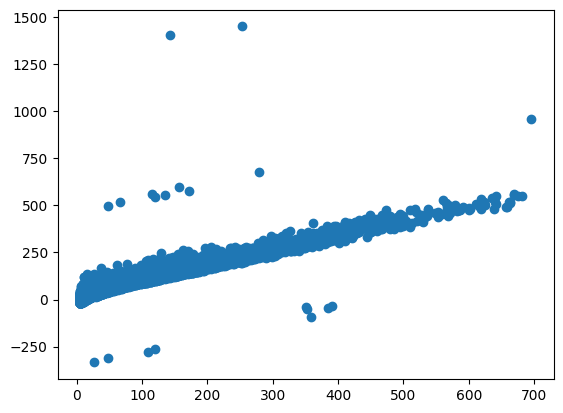

In [13]:
## plot a scatter plot for the prediction
plt.scatter(y_test,reg_pred)

In [14]:
## Residuals
residuals=y_test-reg_pred

In [15]:
residuals

,charging_duration_min
0,-6.631005
1,2.561769
2,13.701242
3,19.676446
4,5.902418
...,...
14984,-3.446181
14985,-7.900263
14986,12.023333
14987,13.915510


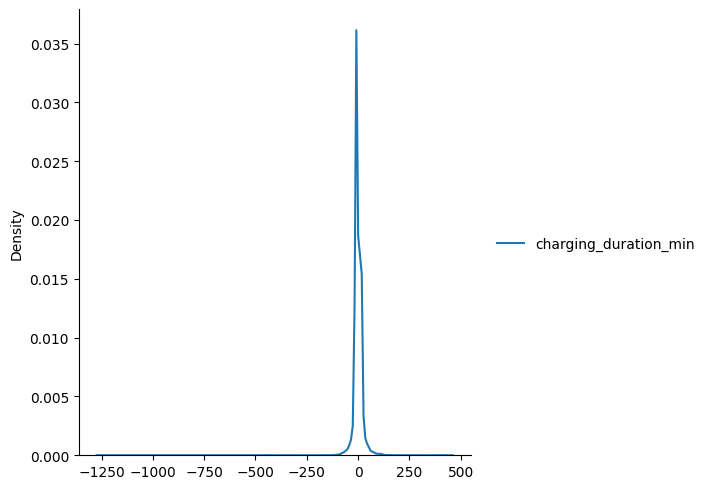

In [16]:
## Plot this residuals 

sns.displot(residuals,kind="kde")

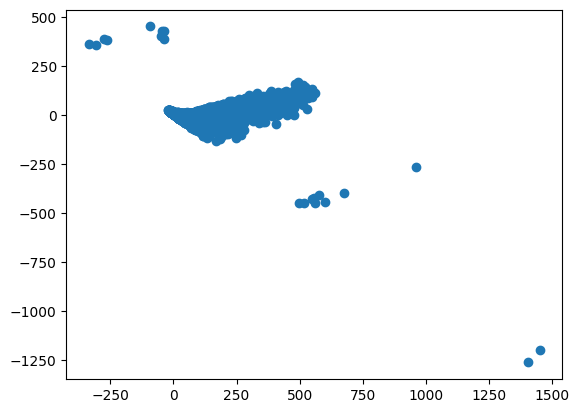

In [17]:
## Scatter plot with respect to prediction and residuals
## uniform distribution
plt.scatter(reg_pred,residuals)

In [18]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

print(mean_absolute_error(y_test,reg_pred))
print(mean_squared_error(y_test,reg_pred))
print(np.sqrt(mean_squared_error(y_test,reg_pred)))

14.174297415414904
775.7673347205482
27.85260014290494


In [19]:
from sklearn.metrics import r2_score
score=r2_score(y_test,reg_pred)
print(score)

0.898400153223931


In [20]:
#display adjusted R-squared
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.8977726568555503

Mean absolute error 14.174297415414904
R2 Score 0.898400153223931


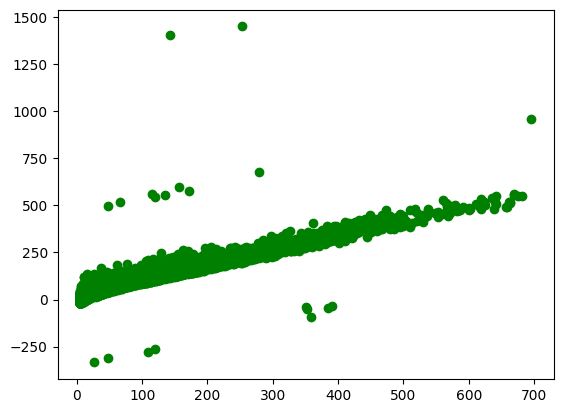

In [21]:
## please check the documentions when ever you have any doubt 
from sklearn.linear_model import LinearRegression ## linear regression model
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
linreg=LinearRegression() ## creating the object of LinearRegression
linreg.fit(X_train,y_train) ## using fit method to train the model
y_pred=linreg.predict(X_test) ## using predict method to predict the values of y based on X_test_scaled
mae=mean_absolute_error(y_test,y_pred) ## MAE
score=r2_score(y_test,y_pred) ## r^2 squared score
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test,y_pred,color='g') ## scatter plot 

Mean absolute error 31.020064800959997
Mean squared error 2026.390400779913
R2 Score 0.734609921024968


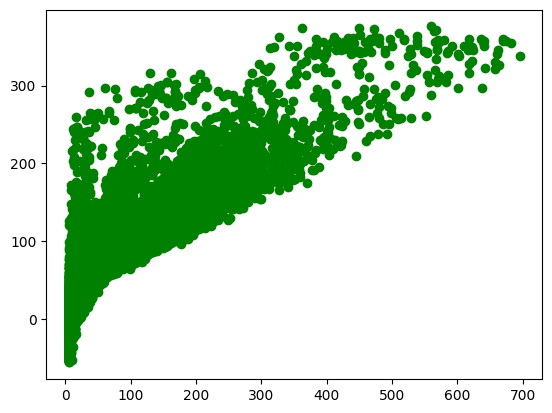

In [22]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error , mean_squared_error
from sklearn.metrics import r2_score
lasso=Lasso() ## creating the object of Lasso
lasso.fit(X_train,y_train) ## using fit method to train the model
y_pred=lasso.predict(X_test) ## using predict method to predict the values of y based on X_test_scaled
mae=mean_absolute_error(y_test,y_pred) ## MAE
mse=mean_squared_error(y_test,y_pred) ## MAE
score=r2_score(y_test,y_pred) ## r^2 squared score
print("Mean absolute error", mae) ## printing MAE
print("Mean squared error", mse) ## printing MSE
print("R2 Score", score) ## printing r^2 score
plt.scatter(y_test,y_pred,color='g') ## scatter plot
## for feature selection we can use lasso regression

Mean absolute error 30.84230669695752
R2 Score 0.7444346607062027


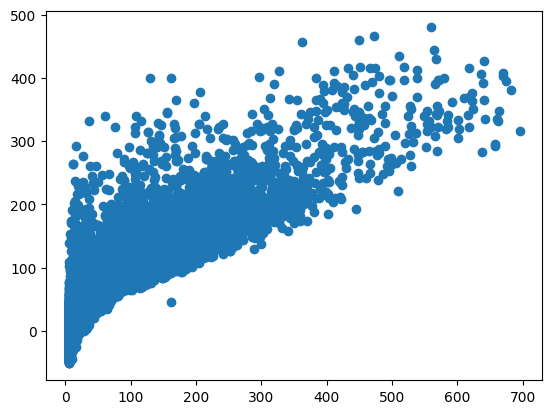

In [23]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
ridge=Ridge()
ridge.fit(X_train,y_train)
y_pred=ridge.predict(X_test)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test,y_pred)
## to reduce overfitting Rigde regression is used

Mean absolute error 32.359149760045376
R2 Score 0.6519086607694742


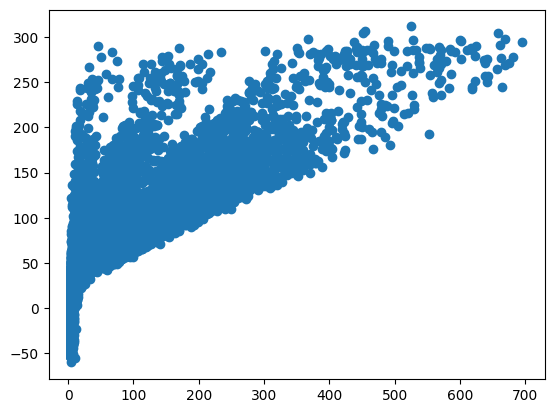

In [24]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
elastic=ElasticNet()
elastic.fit(X_train,y_train)
y_pred=elastic.predict(X_test)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test,y_pred)

In [25]:
elastic

,alpha,1.0
,l1_ratio,0.5
,fit_intercept,True
,precompute,False
,max_iter,1000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [26]:
ridge

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [27]:
lasso

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [28]:
linreg

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [29]:
import pickle
pickle.dump(elastic,open(r"../Saving The Model Results/elastic_net_regression.pkl",'wb'))  # save the scaler model
pickle.dump(ridge,open(r"../Saving The Model Results/ridge_regression.pkl",'wb'))  # save the ridge model
pickle.dump(lasso,open(r"../Saving The Model Results/lasso_regression.pkl",'wb'))  # save the ridge model
pickle.dump(linreg,open(r"../Saving The Model Results/linear_regression.pkl",'wb'))  # save the ridge model
